In [ ]:
from collections import deque

def bidirectional_bfs(graph, start, goal):
    if start == goal:
        return [start]

    q_start = deque([start])
    q_goal = deque([goal])

    visited_start = {start: None}
    visited_goal = {goal: None}

    while q_start and q_goal:
        # Expand from start side
        for _ in range(len(q_start)):
            current = q_start.popleft()
            for neighbor in graph[current]:
                if neighbor not in visited_start:
                    visited_start[neighbor] = current
                    q_start.append(neighbor)

                    if neighbor in visited_goal:
                        return construct_path(visited_start, visited_goal, neighbor)

        # Expand from goal side
        for _ in range(len(q_goal)):
            current = q_goal.popleft()
            for neighbor in graph[current]:
                if neighbor not in visited_goal:
                    visited_goal[neighbor] = current
                    q_goal.append(neighbor)

                    if neighbor in visited_start:
                        return construct_path(visited_start, visited_goal, neighbor)

    return None


def construct_path(visited_start, visited_goal, meeting_node):
    path_start = []
    node = meeting_node
    while node is not None:
        path_start.append(node)
        node = visited_start[node]
    path_start.reverse()

    path_goal = []
    node = visited_goal[meeting_node]
    while node is not None:
        path_goal.append(node)
        node = visited_goal[node]

    return path_start + path_goal


In [10]:
city_map = {
    0: [1, 2],
    1: [0, 3, 4],
    2: [0, 5],
    3: [1],
    4: [1],
    5: [2]
}

# start = 'A'
# goal = 'G'


print("Bi-Directional BFS Nodes Explored:", bidirectional_bfs(city_map, 0, 5))
path = bidirectional_bfs(city_map, 0, 5)
print(path)



Bi-Directional BFS Nodes Explored: [0, 2, 5]
[0, 2, 5]


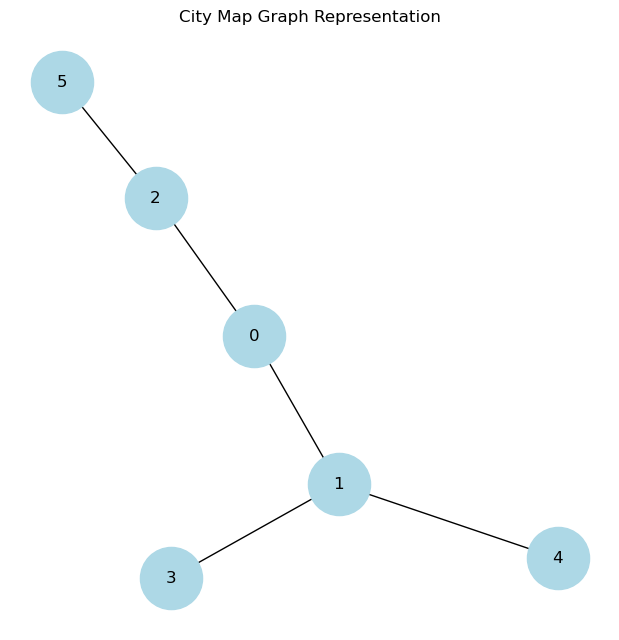

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for node in city_map:
    for neighbor in city_map[node]:
        G.add_edge(node, neighbor)

plt.figure(figsize=(6,6))
nx.draw(G, with_labels=True, node_size=2000, node_color='lightblue')
plt.title("City Map Graph Representation")
plt.show()
